In [101]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

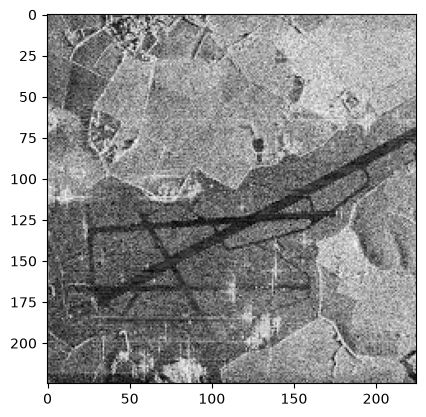

In [102]:
image = cv2.imread('sar_3.jpg')
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY) 
plt.imshow(image_gray, cmap="gray")

#1

In [103]:
edges = cv2.Canny(image_gray, 30, 100)

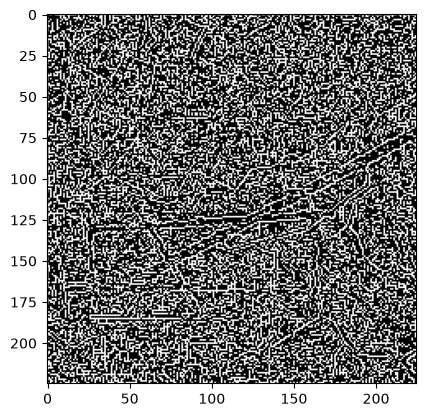

In [104]:
plt.imshow(edges, cmap="gray")

Фильтрация для уменьшения шума

In [105]:
image_blur = cv2.GaussianBlur(image_gray, (9, 9), 0)
edges = cv2.Canny(image_blur, 30, 100)

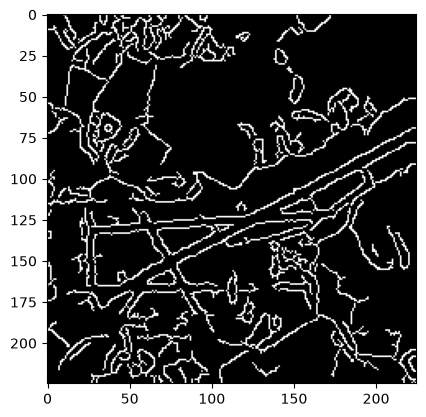

In [106]:
plt.imshow(edges, cmap="gray")

In [107]:
lines = cv2.HoughLines(edges, 1, np.pi / 180, 50)

In [108]:
import math

longest_line = None
max_len = 0

if lines is not None:
    for line in lines:
        rho = lines[i][0][0]
        theta = lines[i][0][1]
        a = math.cos(theta)
        b = math.sin(theta)
        x0 = a * rho
        y0 = b * rho
        
        pt1 = (int(x0 + 1000*(-b)), int(y0 + 1000*(a)))
        pt2 = (int(x0 - 1000*(-b)), int(y0 - 1000*(a)))

        length = math.dist(pt1, pt2)
        
        if length > max_len:
            max_len = length
            longest_line = (pt1, pt2)

In [109]:
image_res = image.copy()
if longest_line is not None:
    pt1, pt2 = longest_line
    cv2.line(image_res, pt1, pt2, (0, 0, 255), 3)

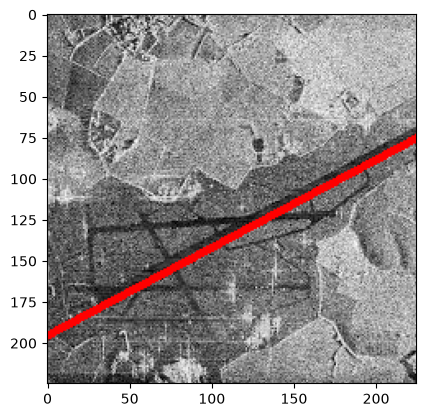

In [110]:
plt.imshow(cv2.cvtColor(image_res, cv2.COLOR_BGR2RGB))

#2 

Точечная 

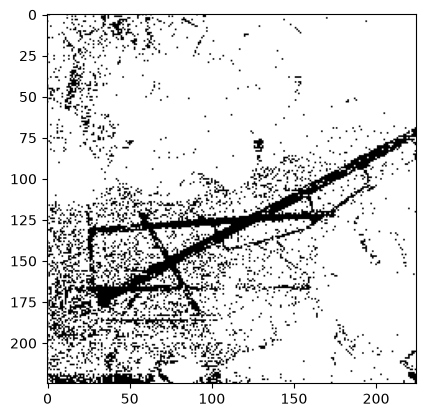

In [122]:
import copy

bin_img = copy.deepcopy(image_gray)
T  = 75
bin_img[image_gray < T] = 0
bin_img[image_gray >= T] = 255
plt.imshow(bin_img, cmap="gray")

Отсу

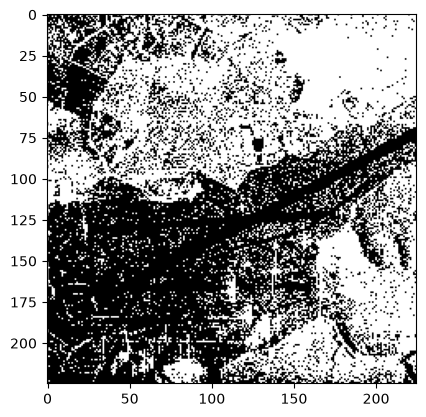

In [116]:
_,th2 = cv2.threshold(image_gray,0,255,cv2.THRESH_BINARY+cv2.THRESH_OTSU)
plt.imshow(th2, cmap="gray")

Адаптивная

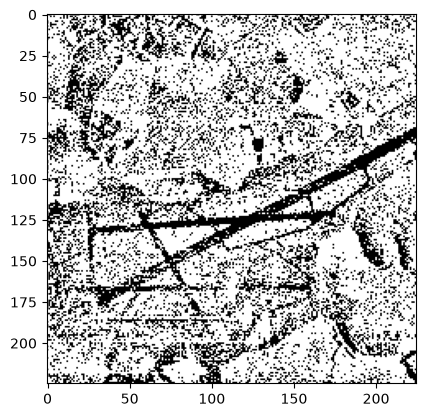

In [117]:
th3 = cv2.adaptiveThreshold(image_gray,255,cv2.ADAPTIVE_THRESH_GAUSSIAN_C,\
            cv2.THRESH_BINARY,71,21)
plt.imshow(th3, cmap="gray")

Лучше всего дорога была выделена при точечной бинаризации(Т = 75)

Бинаризация Отсу завысила порог и очень плохо выделила дорогу

Адаптивная бинаризация неплохо выделила дорогу, но вместе с ней выделила много пикселей на фоне